In [1]:
import numpy as np
import sys
sys.path.append("../src")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards

In [2]:
base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)


In [3]:
def get_close_colors(cmap_name, start=0.5, delta=0.15,n = 2):
    cmap = cm.get_cmap(cmap_name)
    cmap_color = [cmap(start + i*delta) for i in range(n)]
    return cmap_color[:n]

In [4]:

fn = f"../results/PVAFM/GBT_pregrets_gamma0.9_oh_w_time0_2048_lookahead6_10reps.npz"
data = np.load(fn)
PREGRETS_DF_arr = data["pregrets"]
Ts = data['t_list']
Ts = Ts[1:]

fn = f"../results/OnlinePAFM/PVAFM_NN_oh_w_time200_600_lookahead6_10reps.npz"
data = np.load(fn)
PREGRETS_NN_arr = data["pregrets_online"]
# Ts_RL = data["t_list"]


fn = f"../results/OnlinePAFM/PVAFM_NN_oh_w_time0_lookahead6_10reps.npz"
data = np.load(fn)
PREGRETS_NN_init_arr = data["pregrets"]
PREGRETS_NN_arr = np.hstack([PREGRETS_NN_init_arr,PREGRETS_NN_arr])
print(PREGRETS_NN_arr.shape)


(10, 9)


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_29301/1671028746.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


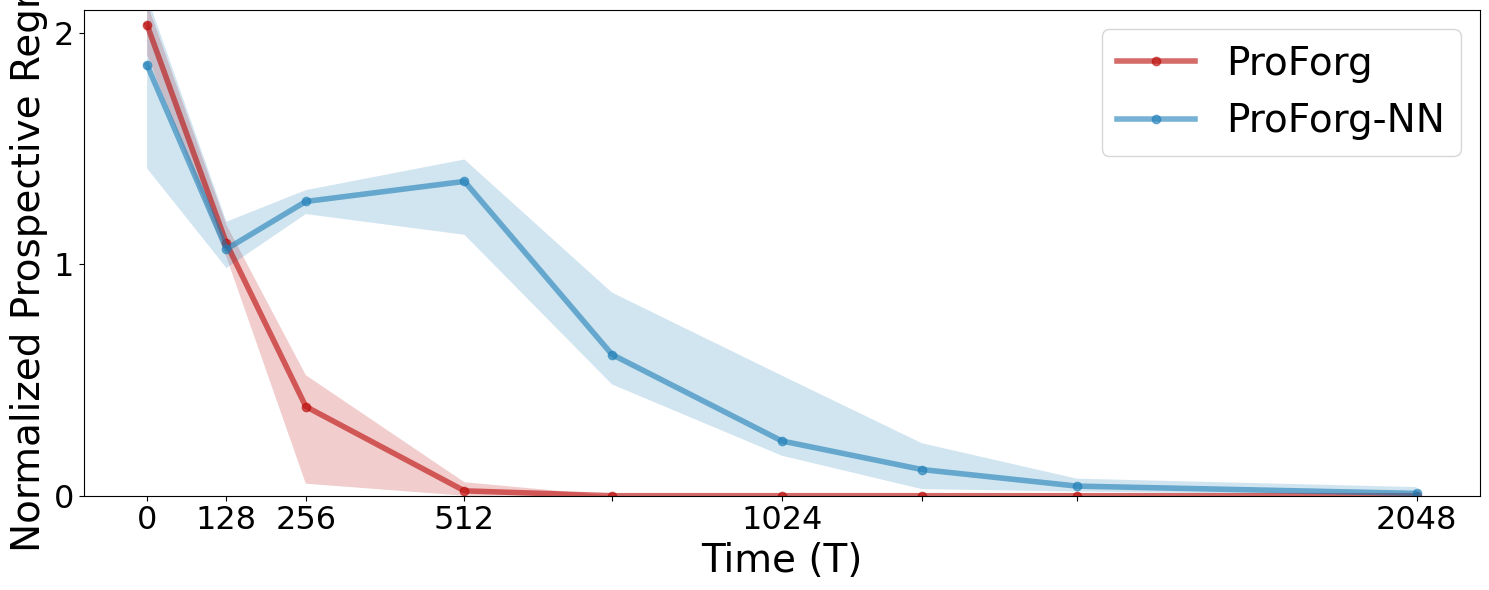

In [ ]:
plt.figure(figsize=(15, 6))
linewidth = 4
fontsize = 28

pafm_df, pvafm_df = get_close_colors("OrRd", start = 0.45, delta = 0.4, n = 2) 
pafm_nn, pafm_nn_opt = get_close_colors("GnBu", start=0.8, delta=0.25,n = 2)
rl_fqi,rl_fqi_notime = get_close_colors("Purples", start=0.7, delta=-0.3,n = 2)
rl_tql,_ = get_close_colors("Greens", start=0.6, delta=0.5,n = 2)
colors = {"PVAFM_oh_RF": pvafm_df,
          "PVAFM_oh_NN": pafm_nn,
          }

## Plot DF
median = np.median(PREGRETS_DF_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_DF_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_DF_arr, 75, axis=0)
plt.plot(Ts, median,color=colors["PVAFM_oh_RF"], lw = linewidth,marker='o',alpha = 0.6,label = 'ProForg')
plt.fill_between(Ts, q25, q75, color=colors["PVAFM_oh_RF"], alpha=0.20, edgecolor="none")


## Plot NN
median = np.median(PREGRETS_NN_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_NN_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_NN_arr, 75, axis=0)
plt.plot(Ts, median,color=colors["PVAFM_oh_NN"], lw = linewidth,marker='o',alpha = 0.6,label = 'ProForg-NN')
plt.fill_between(Ts, q25, q75, color=colors["PVAFM_oh_NN"], alpha=0.20, edgecolor="none")


# median = np.median(PREGRETS_PAFM_NN_arr, axis=0)    
# q25  = np.nanpercentile(PREGRETS_PAFM_NN_arr, 25, axis=0)
# q75  = np.nanpercentile(PREGRETS_PAFM_NN_arr, 75, axis=0)
# plt.plot(Ts_offline, median,color=colors["PVAFM_oh_NN"], lw = linewidth,marker='o',alpha = 0.5,label = 'ProForg-NN')
# plt.fill_between(Ts_offline, q25, q75, color=colors["PVAFM_oh_NN"], alpha=0.10, edgecolor="none")

plt.xlabel("Time (T)",fontsize = fontsize-5)
plt.ylabel("Normalized Prospective Regret", fontsize = fontsize-5)
# plt.xscale('log')

xticks = Ts
xticklabels = [str(v) if v in [0,128,256,512,1024,2048] else ""   # hide every 2nd label
               for i, v in enumerate(xticks)]
plt.xticks(xticks, labels=xticklabels,fontsize = fontsize-5)

# plt.xticks(Ts_PAFM+Ts_PVFM, labels=[str(v) for v in Ts_PAFM+Ts_PVFM])
plt.ylim([0,2.1])
plt.yticks([0,1,2],fontsize = fontsize-5)
# plt.title('Prospective Regret Across Lookahead Steps - ProForg',fontsize = fontsize)
# plt.xlim(0,700000)                  
plt.legend(fontsize = fontsize)
plt.tight_layout()

# plt.grid(True, linestyle='--', alpha=0.2)
# plt.tight_layout()
plt.savefig('ProForg_DFNN.png')

